# 5 Results

Estimate and plot the fundamental frequency of a generated audio file with `librosa`.

In [2]:
import pathlib

import librosa
import matplotlib.pyplot as plt
import numpy as np

cwd = pathlib.Path.cwd()
if cwd.name == "quickstart":
    quickstart_dir = cwd
elif (cwd / "rnencodec-onehot" / "quickstart").exists():
    quickstart_dir = cwd / "rnencodec-onehot" / "quickstart"
else:
    raise FileNotFoundError("Run this notebook from the repo root or from rnencodec-onehot/quickstart.")

quickstart_dir

PosixPath('/Users/oriolfreixa/Documents/GitHub/GenAI/rnencodec-onehot/quickstart')

In [3]:
def plot_fundamental_frequency(
    audio_path,
    *,
    sr=None,
    fmin=65.41,
    fmax=2093.0,
    frame_length=2048,
    hop_length=256,
):
    """Load an audio file, estimate its F0 with librosa, and plot it over time."""
    audio_path = pathlib.Path(audio_path)
    if not audio_path.is_absolute() and not audio_path.exists():
        audio_path = (quickstart_dir / audio_path).resolve()

    if not audio_path.exists():
        raise FileNotFoundError(f"Audio file not found: {audio_path}")

    fmin_hz = float(fmin)
    fmax_hz = float(fmax)
    if fmin_hz >= fmax_hz:
        raise ValueError("fmin must be lower than fmax.")

    y, sr = librosa.load(audio_path, sr=sr, mono=True)
    f0, voiced_flag, voiced_prob = librosa.pyin(
        y,
        sr=sr,
        fmin=fmin_hz,
        fmax=fmax_hz,
        frame_length=frame_length,
        hop_length=hop_length,
    )
    times = librosa.times_like(f0, sr=sr, hop_length=hop_length)

    voiced_f0 = f0[~np.isnan(f0)]
    plt.figure(figsize=(12, 4))
    plt.plot(times, f0, color="tab:blue", linewidth=1.5, label="Estimated F0")
    plt.scatter(times[voiced_flag], f0[voiced_flag], s=10, color="tab:orange", alpha=0.6, label="Voiced frames")
    plt.title(f"Fundamental Frequency: {audio_path.name}")
    plt.xlabel("Time (s)")
    plt.ylabel("Frequency (Hz)")
    plt.ylim(0, fmax_hz * 1.05)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    if voiced_f0.size:
        print(f"Voiced frames: {voiced_f0.size}/{f0.size}")
        print(f"Median F0: {np.median(voiced_f0):.2f} Hz")
        print(f"Mean F0: {np.mean(voiced_f0):.2f} Hz")
    else:
        print("No voiced frames were detected in the selected range.")

    return times, f0, voiced_prob


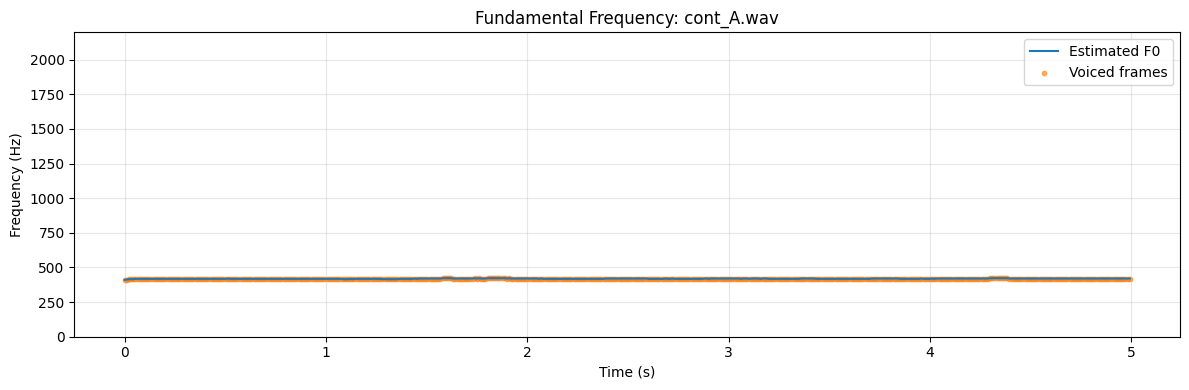

Voiced frames: 469/469
Median F0: 417.73 Hz
Mean F0: 418.90 Hz


In [4]:
audio_path = quickstart_dir / "experiments_output" / "cont_A.wav"
times, f0, voiced_prob = plot_fundamental_frequency(audio_path)

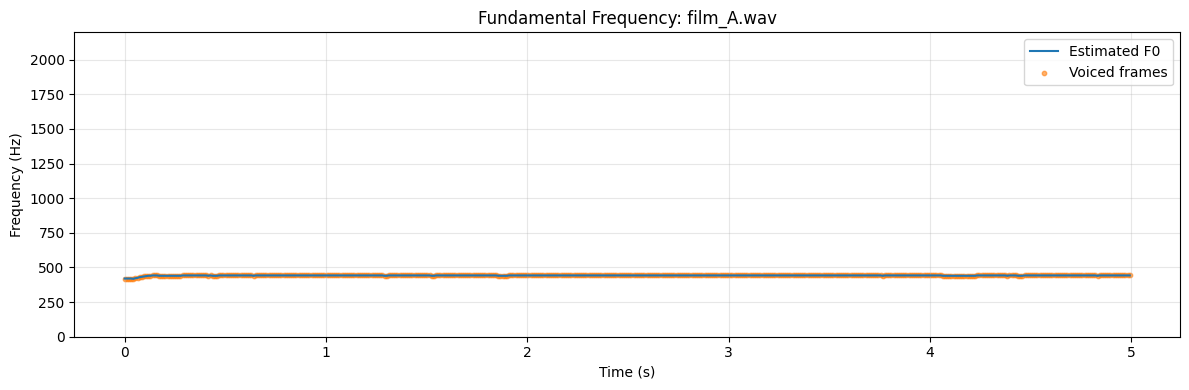

Voiced frames: 469/469
Median F0: 442.57 Hz
Mean F0: 441.91 Hz


In [6]:
audio_path = quickstart_dir / "experiments_output" / "film_A.wav"
times, f0, voiced_prob = plot_fundamental_frequency(audio_path)